# Random Forest Model

In this section, we implement the Random Forest classifier as an ensemble model for phishing website detection.

Random Forest builds multiple decision trees and combines their predictions through majority voting. This reduces overfitting compared to a single decision tree.

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load Clean Dataset
df = pd.read_csv("../../data/processed-phishing.csv")

In [3]:
# Separate features and target variable
X = df.drop("Result", axis=1)
y = df["Result"]

print(X.shape)
print(y.shape)

(5849, 30)
(5849,)


In [4]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# Tune Random Forest on train set using CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
rf = grid.best_estimator_

cv_results = cross_validate(
    rf,
    X_train,
    y_train,
    cv=skf,
    scoring=["accuracy", "precision", "recall", "f1"],
    n_jobs=-1,
)
print("Best Params:", grid.best_params_)
print(f"CV Accuracy: {cv_results['test_accuracy'].mean():.4f} +/- {cv_results['test_accuracy'].std():.4f}")
print(f"CV Accuracy Variance: {cv_results['test_accuracy'].var():.6f}")

# Train best model and predict test
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

Best Params: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
CV Accuracy: 0.9464 +/- 0.0109
CV Accuracy Variance: 0.000119


In [6]:
# Evaluate the tuned model
print("Random Forest (Tuned with CV) Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest (Tuned with CV) Results:

Accuracy: 0.9435897435897436
Precision: 0.9385964912280702
Recall: 0.9452296819787986
F1 Score: 0.9419014084507042

Confusion Matrix:
[[569  35]
 [ 31 535]]


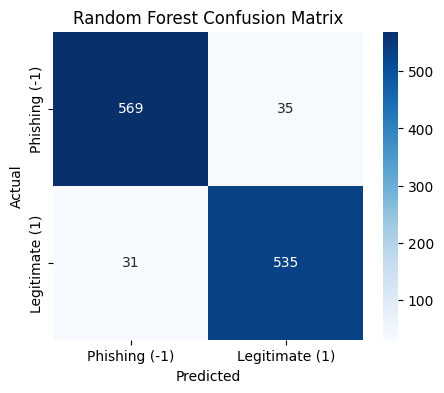

In [7]:
# Confusion Matrix Visualization
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing (-1)", "Legitimate (1)"],
    yticklabels=["Phishing (-1)", "Legitimate (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

## Results

The Random Forest model achieved strong performance on the phishing detection task.

Compared to the single Decision Tree model, Random Forest improves accuracy by combining multiple trees. This reduces the variance and helps the model generalize better to unseen data.

From the confusion matrix, the model correctly classifies most phishing and legitimate websites with relatively few misclassifications in both directions.

In [8]:
# Check for overfitting
y_train_pred_rf = rf.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred_rf))
print("Test Accuracy:", accuracy_score(y_test, y_pred_rf))

Train Accuracy: 0.9809788416328276
Test Accuracy: 0.9435897435897436


### Overfitting Analysis

The Random Forest model shows a high training accuracy and a lower test accuracy, which indicates some degree of overfitting. However, this is typical for Random Forest models and the test accuracy is still strong.

Compared to the single Decision Tree, Random Forest still generalizes better overall due to the ensemble averaging effect.

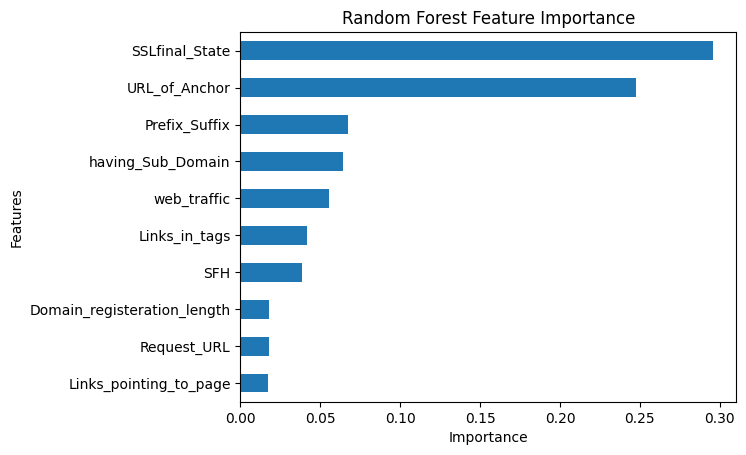


Top 10 Important Features:
SSLfinal_State                 0.295626
URL_of_Anchor                  0.247496
Prefix_Suffix                  0.067082
having_Sub_Domain              0.064012
web_traffic                    0.055202
Links_in_tags                  0.041755
SFH                            0.038262
Domain_registeration_length    0.017747
Request_URL                    0.017727
Links_pointing_to_page         0.017570
dtype: float64


In [9]:
# Feature Importance
feat_importance = pd.Series(rf.feature_importances_, index=X.columns)
feat_importance = feat_importance.sort_values(ascending=False)

feat_importance.head(10).plot(kind='barh')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

print()
print("Top 10 Important Features:")
print(feat_importance.head(10))

## Feature Analysis

Random Forest provides built-in feature importance based on how much each feature contributes to reducing impurity across all trees.

The most important features include:
- SSLfinal_State
- URL_of_Anchor
- having_Sub_Domain
- web_traffic
- Prefix_Suffix

These features are consistent with what the Decision Tree and other models found, confirming that SSL status, URL structure, and domain characteristics are the strongest indicators of phishing websites.

## Random Forest Summary

The Random Forest model demonstrates strong performance as an ensemble classifier for phishing detection. By combining multiple decision trees, it achieves better generalization than a single Decision Tree.

The model achieves high accuracy with balanced precision and recall. Feature importance analysis confirms that the same key features (SSL state, URL structure, subdomain) are driving the classification.

Random Forest serves as a strong ensemble baseline that can be compared against boosting methods like XGBoost and LightGBM.